In [4]:
import os
env = os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5000")
env

'http://localhost:5000'

In [6]:
from tensorflow import keras

(X, y), (x_test, y_test) = keras.datasets.mnist.load_data()
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np


X_df = pd.DataFrame(X.reshape(X.shape[0], -1))
# X_df = X_df.drop_duplicates()
y_df = pd.DataFrame(y, columns=['target'])
print("Shape of X_df:", X_df.shape)
print("Shape of y_df:", y_df.shape)


Shape of X_df: (60000, 784)
Shape of y_df: (60000, 1)


In [7]:
# sauvegarde des données dans le dossier data
import os
os.makedirs("./data", exist_ok=True)
df_full = X_df.copy()
df_full['target'] = y_df['target']
df_full.to_csv("./data/mnist_full.csv", index=False)
print("Données MNIST sauvegardées dans le fichier mnist_full.csv du dossier data.")

Données MNIST sauvegardées dans le fichier mnist_full.csv du dossier data.


In [ ]:
import sys
sys.path.append('../models')  # ou le chemin relatif vers le dossier models

from keras_mnist_models import (
    create_nn_model,
    train_model,
    model_predict,
    model_evaluate,
    model_preprocess,
    model_print_draw,
    draw_loss
)

print('Fonctions importées depuis keras_mnist_models.py')

In [8]:
import pandas as pd
import sys

# Charger le fichier CSV
file_path = "./data/mnist_full.csv"
df = pd.read_csv(file_path)

def showimg(df, index):
    if index < 0 or index >= len(df):
        print(f"Index {index} hors limites (0-{len(df)-1})")
        sys.exit(1)

    row = df.iloc[index]
    X = row.drop('target').values.reshape(28, 28)
    y = row['target']

    print(f"Label (target) : {y}")

    try:
        import matplotlib.pyplot as plt
        plt.imshow(X, cmap='gray')
        plt.title(f"Index {index} - Label: {y}")
        plt.axis('off')
        plt.show()
    except ImportError:
        print("matplotlib n'est pas installé, affichage image impossible.")
   

Label (target) : 7


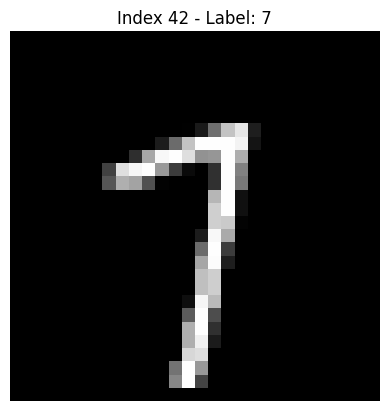

In [11]:
showimg(df, 42)